##### Copyright 2025 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# 2D spatial understanding with Gemini 2.0

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

This notebook introduces object detection and spatial understanding with the Gemini API like in the [Spatial understanding example](https://aistudio.google.com/starter-apps/spatial) from [AI Studio](https://aistudio.google.com) and demonstrated in the [Building with Gemini 2.0: Spatial understanding](https://www.youtube.com/watch?v=-XmoDzDMqj4) video.

You'll learn how to use Gemini the same way as in the demo and perform object detection like this:
<img src="https://storage.googleapis.com/generativeai-downloads/images/cupcakes_with_bbox.png" />

There are many examples, including object detection with

* simply overlaying information
* searching within an image
* translating and understanding things in multiple languages
* using Gemini thinking abilities

**Note**

There's no "magical prompt". Feel free to experiment with different ones. You can use the dropdown to see different samples, but you can also write your own prompts. Also, you can try uploading your own images.

----

## Setup

### Install SDK

The new **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides programmatic access to Gemini 2.0 (and previous models) using both the [Google AI for Developers](https://ai.google.dev/gemini-api/docs/models/gemini-v2) and [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview) APIs. With a few exceptions, code that runs on one platform will run on both. This means that you can prototype an application using the Developer API and then migrate the application to Vertex AI without rewriting your code.

More details about this new SDK on the [documentation](https://googleapis.github.io/python-genai/) or in the [Getting started](../quickstarts/Get_started.ipynb) notebook.

In [ ]:
%pip install -U -q google-genai

### Setup your API key

To run the following cell, your API key must be stored in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](../quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata
import os

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

### Initialize SDK client

With the new SDK you now only need to initialize a client with your API key.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

### Select and configure a model

Spatial understanding works best [Gemini 2.0 Flash model](https://ai.google.dev/gemini-api/docs/models/gemini-v2). It's even better with 2.5 models like `gemini-2.5-pro-exp-03-25` but slightly slower as it's a [thinking](./Get_started_thinking.ipynb) model.

Some features, like segmentation, only works with 2.5 models.

You can try with the older ones but it might be more inconsistent (`gemini-1.5-flash-001` had the best results of the previous generation). The [Object detection](https://github.com/google-gemini/cookbook/blob/gemini-1.5-archive/examples/Object_detection.ipynb) contains good examples of what previous models were able to do.

For more information about all Gemini models, check the [documentation](https://ai.google.dev/gemini-api/docs/models/gemini) for extended information on each of them.

In [ ]:
model_name = "gemini-2.5-pro-exp-03-25" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-pro-exp-03-25"] {"allow-input":true}

The system instructions are mainly used to make the prompts shorter by not having to reapeat each time the format. They are also telling the model how to deal with similar objects which is a nice way to let it be creative.

The [Spatial understanding example](https://aistudio.google.com/starter-apps/spatial) is using a different strategy with no system instructions but a longer prompt. You can see their full prompts by clicking on the "show raw prompt" button on the right. There no optimal solution, experiment with diffrent strategies and find the one that suits your use-case the best.

### Import

Import all the necessary modules.

In [ ]:
import google.generativeai as genai
from PIL import Image

import io
import os
import requests
from io import BytesIO

### Utils

Some scripts will be needed to draw the bounding boxes. Of course they are just examples and you are free to just write your own.

For example the [Spatial understanding example](https://aistudio.google.com/starter-apps/spatial) from [AI Studio](https://aistudio.google.com) uses HML to render the bounding boxes. You can find its code in the [Github repo](https://github.com/google-gemini/starter-applets/tree/main/spatial).

In [ ]:
# @title Parsing JSON output
def parse_json(json_output: str):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output

```json
[
  {"box_2d": [278, 804, 469, 936], "mask": "", "label": "glass jar with sprinkles"},
  {"box_2d": [263, 703, 432, 810], "mask": "", "label": "glass jar with white powder"},
  {"box_2d": [706, 655, 868, 951], "mask": "", "label": "wooden spoon"},
  {"box_2d": [73, 442, 168, 508], "mask": "", "label": "wooden spoon"},
  {"box_2d": [278, 818, 333, 934], "mask": "", "label": "metal lid"},
  {"box_2d": [263, 706, 310, 810], "mask": "", "label": "metal lid"},
  {"box_2d": [186, 100, 361, 230], "mask": "", "label": "glass jar with sprinkles"},
  {"box_2d": [206, 552, 274, 889], "mask": "", "label": "wooden rolling pin"},
  {"box_2d": [186, 102, 219, 218], "mask": "", "label": "metal lid"},
  {"box_2d": [194, 249, 331, 381], "mask": "", "label": "metal container"},
  {"box_2d": [772, 798, 812, 1000], "mask": "", "label": "wooden spoon"},
  {"box_2d": [274, 630, 376, 708], "mask": "", "label": "metal bowl"},
  {"box_2d": [56, 231, 213, 321], "mask": "", "label": "wooden utensil"},
  {
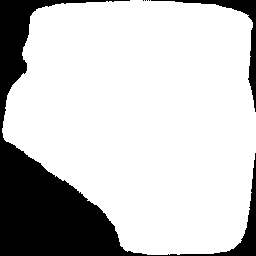
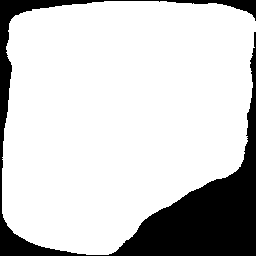
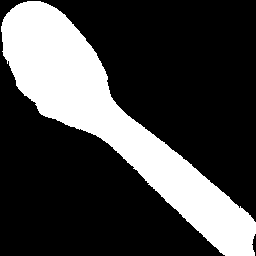
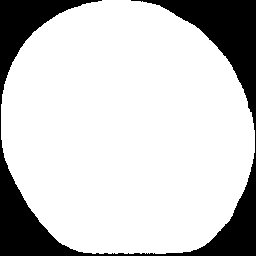
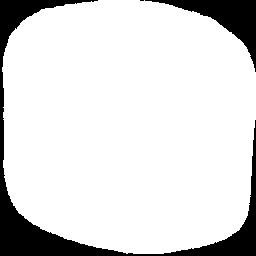
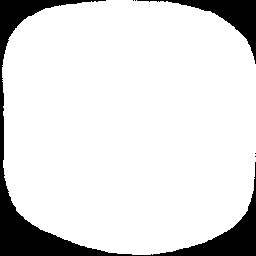
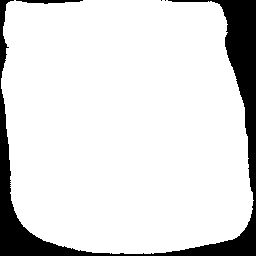
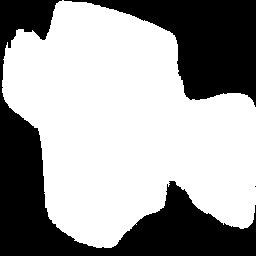
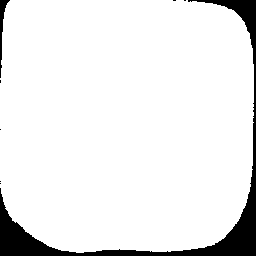
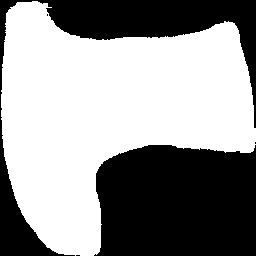
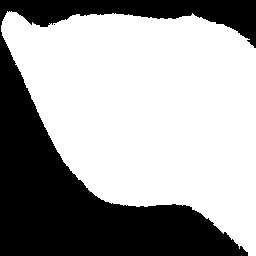
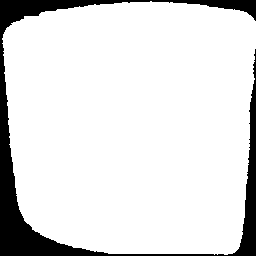
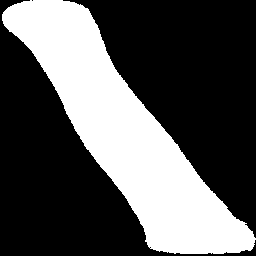
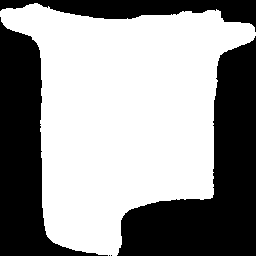
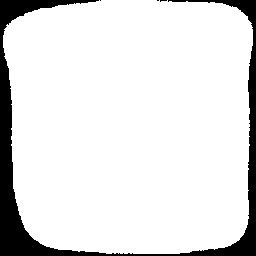
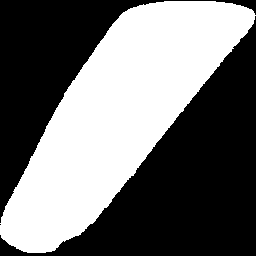
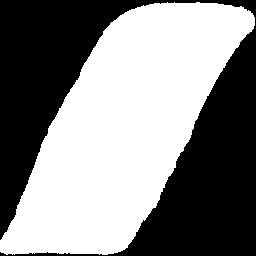
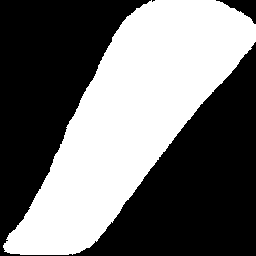
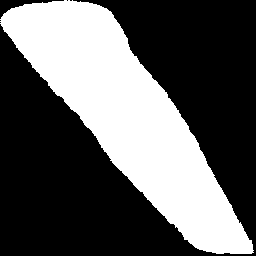

In [ ]:
import requests
from io import BytesIO
from PIL import Image, ImageEnhance, ImageFilter
import pytesseract
import re

# URL de la imagen
image_url = "https://farmacityar.vtexassets.com/arquivos/ids/254903-1200-auto?v=638506137049230000&width=1200&height=auto&aspect=true"

# Preprocesamiento de la imagen para mejorar OCR
try:
    response = requests.get(image_url)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa
    image_data = response.content
    im = Image.open(BytesIO(image_data))
except requests.exceptions.RequestException as e:
    print(f"Error al descargar la imagen: {e}")
    exit()
except Exception as e:
    print(f"Error al procesar la imagen: {e}")
    exit()

# Convertir a escala de grises para mejorar el contraste
im = im.convert("L")

# Aplicar filtro de mejora de contraste
enhancer = ImageEnhance.Contrast(im)
im = enhancer.enhance(2)  # Aumentar el contraste

# Aplicar filtro de suavizado para eliminar ruido
im = im.filter(ImageFilter.MedianFilter())

# Binarización (convertir a blanco y negro) para mejorar el rendimiento del OCR
threshold = 180  # Umbral de binarización más alto
im = im.point(lambda p: p > threshold and 255)

# Aumentar el tamaño de la imagen para mejorar la precisión del OCR
im = im.resize((im.width * 2, im.height * 2), Image.Resampling.LANCZOS)

# Usar pytesseract para extraer el texto de la imagen
try:
    extracted_text = pytesseract.image_to_string(im, lang='spa')  # Especificamos el idioma español
except pytesseract.TesseractError as e:
    print(f"Error de Tesseract: {e}")
    exit()

# Imprimir el texto extraído para ayudar a identificar la información del producto
print("Texto extraído de la imagen:")
print(extracted_text)

# Listas de productos (como en tu código original)
productos_dermatologia = [
    "Gel limpiador facial", "Jabón de cara", "Jabón corporal", "Exfoliante facial", "Exfoliante corporal",
    "Hidratante facial", "Crema hidratante corporal", "Crema para piel seca", "Crema antiarrugas",
    "Sérum antienvejecimiento", "Mascarilla facial hidratante", "Mascarilla purificante", "Mascarilla exfoliante",
    "Cremas con ácido hialurónico", "Cremas con vitamina C", "Cremas con retinol", "Protector solar facial",
    "Protector solar corporal", "Crema para quemaduras solares", "Crema para rosácea", "Crema para psoriasis",
    "Tratamiento para acné", "Geles antiacné", "Crema para dermatitis atópica", "Crema para la piel sensible",
    "Cremas con niacinamida", "Cremas despigmentantes", "Tratamientos para manchas solares",
    "Tratamiento para hiperpigmentación", "Gel calmante para irritaciones", "Crema para cicatrices", "Crema para estrías",
    "Tónico facial", "Tónico astringente", "Gel refrescante para piernas cansadas", "Crema para quemaduras",
    "Aceite para piel seca", "Aceite esencial para la piel", "Crema para uñas quebradizas", "Crema para pies secos",
    "Crema para manos secas", "Cremas para piel grasa", "Cremas para piel mixta", "Desodorante sin alcohol",
    "Desodorante antitranspirante", "Cremas para cuidado de tatuajes", "Gel para el cuidado del cuero cabelludo",
    "Aceite de rosa mosqueta", "Aceite de argán", "Bálsamo para labios", "Crema para ojos (antiarrugas)",
    "Crema para ojeras", "Crema de contorno de ojos", "Exfoliante de labios", "Crema reparadora para la piel",
    "Crema para cicatrices quirúrgicas", "Pomada antibiótica para la piel", "Crema con colágeno",
    "Mascarilla facial anti-edad", "Spray refrescante facial", "Aceite corporal hidratante", "Tónico calmante",
    "Loción corporal para piel seca", "Cremas para piel con acné rosáceo", "Crema antimicrobiana para la piel",
    "Cremas para picazón o prurito", "Crema para dermatitis seborreica", "Geles para estrías", "Mascarilla capilar reparadora",
    "Shampoo para cuero cabelludo sensible", "Aceite para el cabello seco", "Geles antibacterianos para la piel",
    "Pomada para hongos en la piel"]
productos_maquillaje = ["Base de maquillaje", "Base en polvo", "Base líquida", "Base en crema", "Corrector de ojeras",
    "Corrector de imperfecciones", "Polvo traslúcido", "Polvo compacto", "Blush (rubor)", "Bronzer",
    "Highlighter (iluminador)", "Contorno facial", "Sérum de maquillaje", "Primers o prebases de maquillaje",
    "Spray fijador de maquillaje", "Pintalabios", "Brillo de labios", "Lápiz labial mate", "Lápiz labial líquido",
    "Lápiz para cejas", "Gel para cejas", "Sombra de ojos", "Sombra en crema", "Sombra en polvo",
    "Delineador de ojos", "Delineador líquido", "Delineador en gel", "Delineador en lápiz", "Máscara de pestañas (rímel)",
    "Tintes para cejas", "Tinte de pestañas", "Fijador de cejas", "Desmaquillante facial", "Desmaquillante de ojos",
    "Toallitas desmaquillantes", "Aceite desmaquillante", "Limpiador bifásico", "Limpiador micelar",
    "Crema para desmaquillar", "Exfoliante facial de maquillaje", "Spray fijador de cejas", "Pestañas postizas",
    "Pegamento para pestañas postizas", "Bálsamo reparador de labios", "Exfoliante labial", "Kit para cejas",
    "Sombra de cejas en polvo", "Tinte para labios", "Pintura para cara (body paint)", "Brillo de cuerpo",
    "Cejas en gel", "Cejas en lápiz", "Base con SPF (protección solar)", "Líquido matificante para rostro",
    "Póster para rostro (para igualar el tono de piel)"]
productos_higiene = ["Shampoo", "Acondicionador", "Jabón de cuerpo", "Gel de baño", "Exfoliante corporal",
    "Desodorante", "Pasta de dientes", "Enjuague bucal", "Bálsamo para labios", "Gel para el cuidado del cuero cabelludo",
    "Cepillo de dientes", "Jabón en barra", "Jabón líquido para manos", "Toallitas húmedas", "Desinfectante para manos",
    "Toallitas desmaquillantes", "Jabón antibacteriano"]

# Función para identificar el tipo de producto y el nombre
def identificar_producto(texto):
    # Buscar con expresiones regulares para identificar el producto más eficientemente
    for categoria, productos in [("Dermatología", productos_dermatologia),
                                 ("Maquillaje", productos_maquillaje),
                                 ("Higiene", productos_higiene)]:
        for producto in productos:
            # Usamos una expresión regular para detectar una coincidencia insensible a mayúsculas/minúsculas
            if re.search(r'\b' + re.escape(producto.lower()) + r'\b', texto.lower()):
                return f"Tipo de producto: {categoria}\nInfo: {producto}"

    return "Producto no reconocido o información incompleta"

# Llamar a la función para identificar el producto
resultado = identificar_producto(extracted_text)
print(resultado)


The model predicts a JSON list, where each item represents a segmentation mask. Each item has a bounding box ("`box_2d`") in the format `[y0, x0, y1, x1]` with normalized coordinates between 0 and 1000, a label ("`label`") that identifies the object, and lastly the segmentation mask inside the bounding box, as base64 encoded png.

To use the mask, first you need to do base64 decoding, and then loading this string as a png. This will give you a probability map with values between 0 and 255. The mask needs to be resized to match the bounding box dimensions, then you can apply your confidence threshold, e.g. binarizing at 127 for the midpoint. Finally, pad the mask into an array of the size of the full image.

All these steps are done by the the `parse_segmentation_masks` function provided earlier.

Ultimately, use the `plot_segmentation_masks` function to visualize the decoded masks by overlaying it on the image.

In [ ]:
segmentation_masks = parse_segmentation_masks(response.text, img_height=im.size[1], img_width=im.size[0])

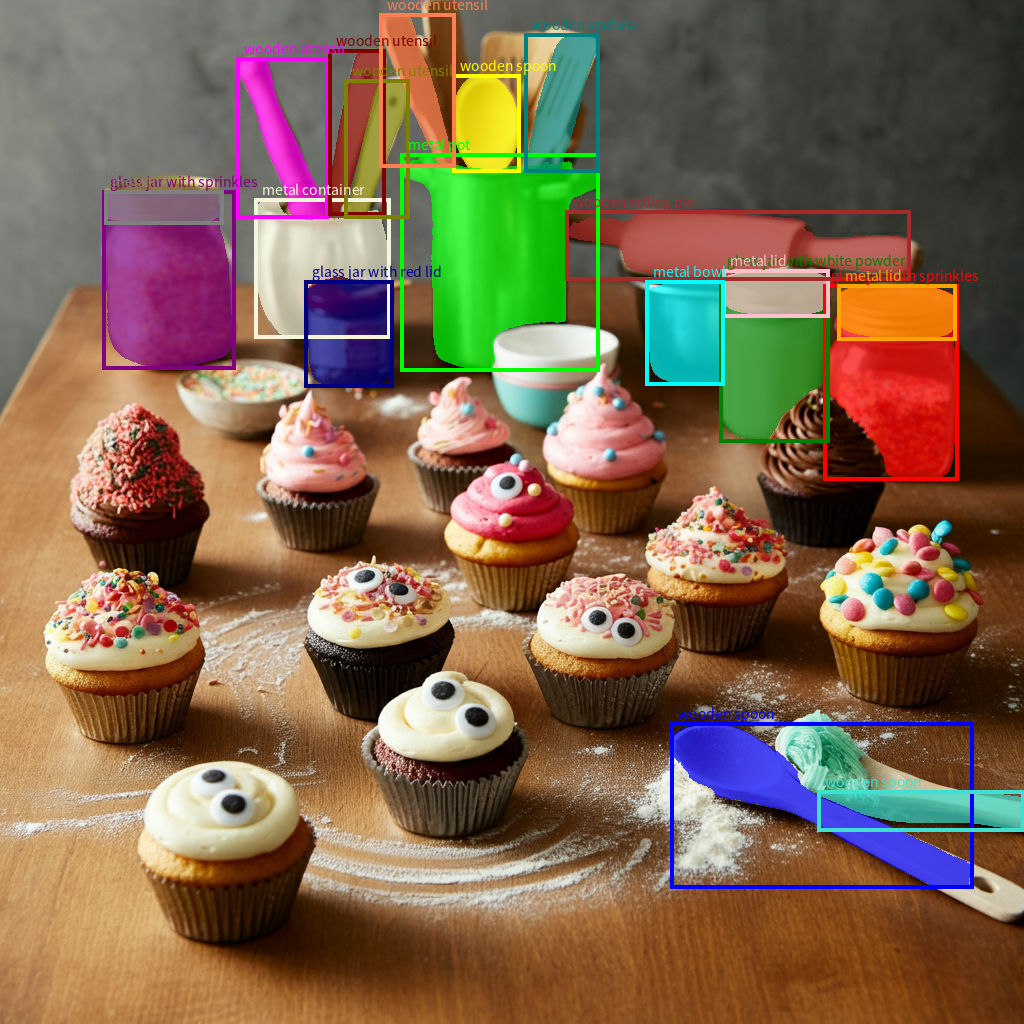

In [ ]:
plot_segmentation_masks(im, segmentation_masks)

## Preliminary capabilities: pointing and 3D boxes

Pointing and 3D bounding boxes are experimental model capabilities. Check this [other notebook](../examples/Spatial_understanding_3d.ipynb) to get a sneak peek on those upcoming capabilities.

<a href="../examples/Spatial_understanding_3d.ipynb"><img src="https://storage.googleapis.com/generativeai-downloads/images/box_3d.png" height="400"/></a>

## What's next?

For a more end-to-end example, the code from the [AI Studio Spatial understanding example](https://aistudio.google.com/starter-apps/spatial)  is available on [Github](https://github.com/google-gemini/starter-applets/tree/main/spatial).

You'll also find multiple other examples of Gemini 2.0 capabilities in the [Gemini 2.0 cookbook](https://github.com/google-gemini/cookbook/tree/main/gemini-2/), in particular the [Live API](./Get_started_LiveAPI.ipynb) and the [video understanding](./Video_understanding.ipynb) one.

Related to image recognition and reasoning, [Market a jet backpack](../examples/Market_a_Jet_Backpack.ipynb) and [Guess the shape](../examples/Guess_the_shape.ipynb) examples are worth checking to continue your Gemini API discovery (Note: these examples still use the old SDK). And of course the [pointing and 3d boxes](../examples/Spatial_understanding_3d.ipynb) example referenced earlier.